In [36]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.preprocessing import StandardScaler  
from sklearn.cluster import KMeans  
from sklearn.metrics import silhouette_score  
import scipy.cluster.hierarchy as sch  
from sklearn.cluster import DBSCAN  
from sklearn.mixture import GaussianMixture  

In [37]:
data = pd.read_csv('Customer.csv')  

Data Cleaning

In [38]:
missing_values = data.isna().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


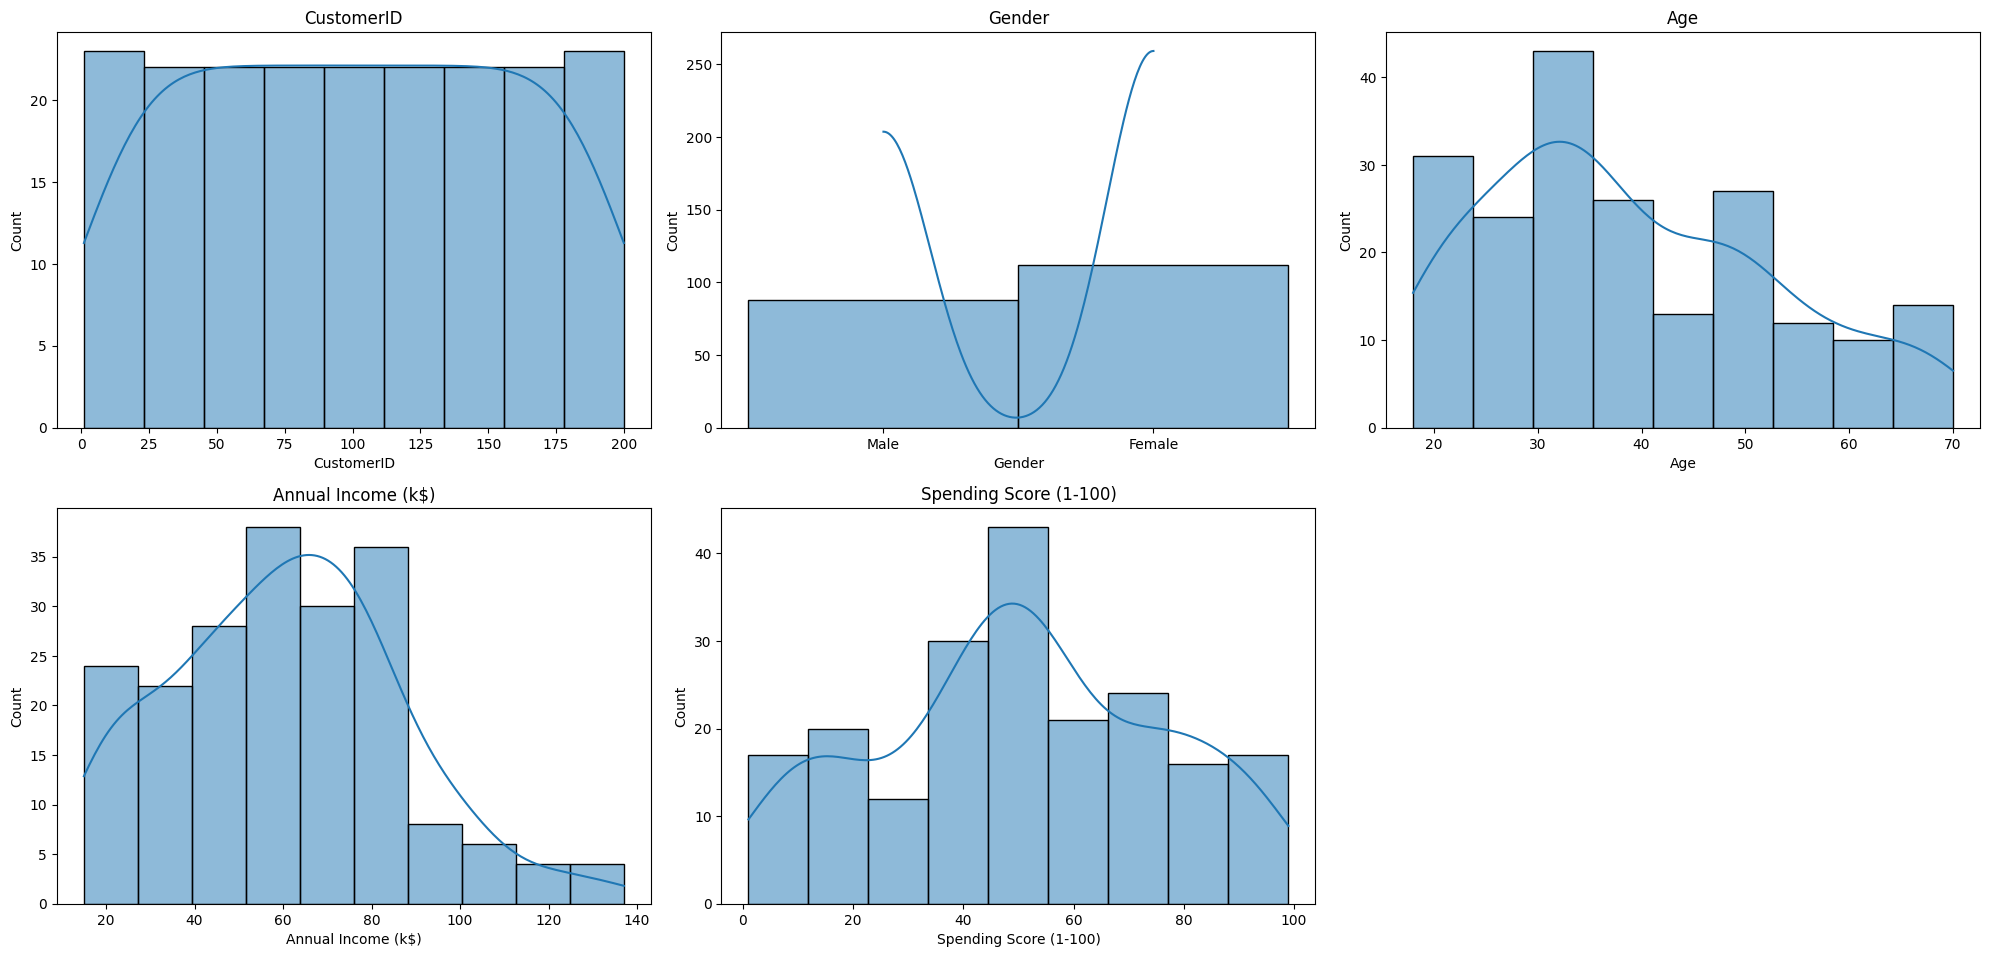

In [39]:
plt.figure(figsize=(20, 14))  
for i, col in enumerate(data.columns):  
    plt.subplot(3, 3, i+1)  
    sns.histplot(data[col], kde=True)  
    plt.title(col)  
plt.tight_layout()  
plt.show()

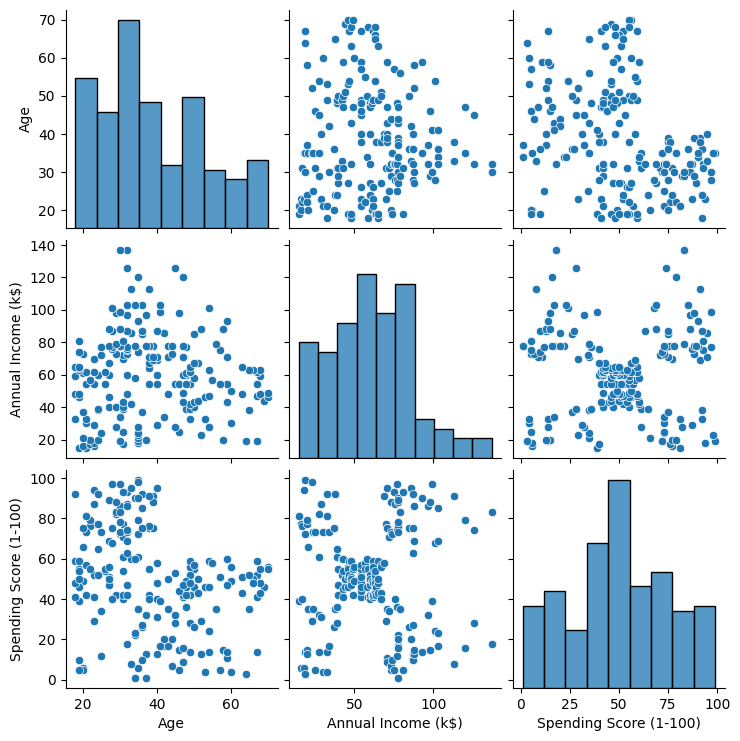

In [40]:
sns.pairplot(data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])  
plt.show()

Clustering

In [41]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]  
scaler = StandardScaler()  
X_scaled = scaler.fit_transform(X) 

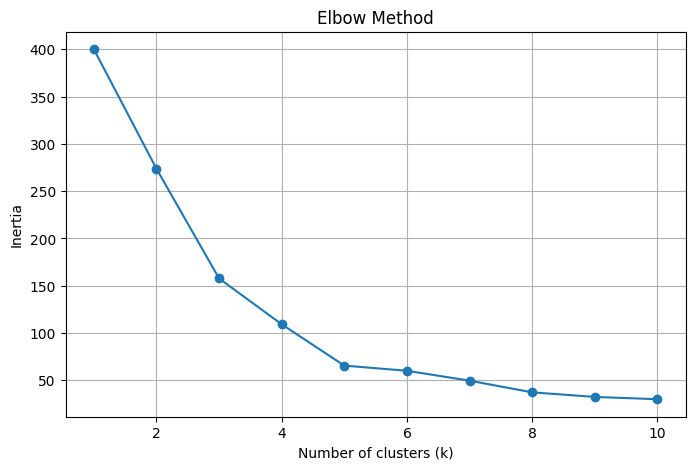

In [42]:
inertia = []  
for k in range(1, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42)  
    kmeans.fit(X_scaled)  
    inertia.append(kmeans.inertia_)  
 
plt.figure(figsize=(8, 5))  
plt.plot(range(1, 11), inertia, marker='o')  
plt.title('Elbow Method')  
plt.xlabel('Number of clusters (k)')  
plt.ylabel('Inertia')  
plt.grid()  
plt.show()

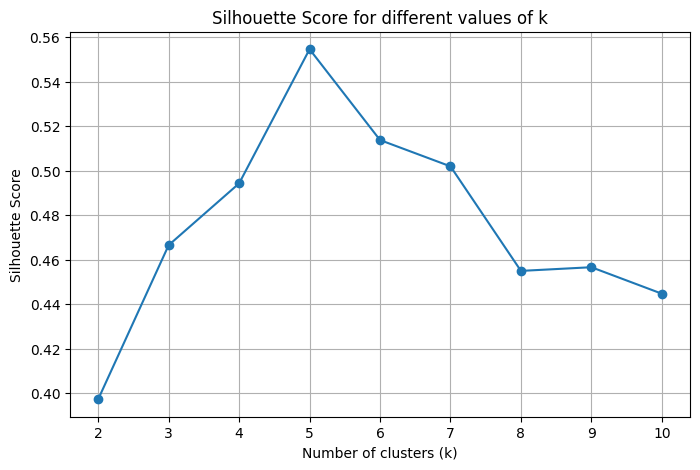

In [48]:
silhouette_scores = []  
for k in range(2, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42)  
    labels = kmeans.fit_predict(X_scaled)  
    silhouette_scores.append(silhouette_score(X_scaled, labels)) 

plt.figure(figsize=(8, 5))  
plt.plot(range(2, 11), silhouette_scores, marker='o')  
plt.title('Silhouette Score for different values of k')  
plt.xlabel('Number of clusters (k)')  
plt.ylabel('Silhouette Score')  
plt.grid()  
plt.show() 

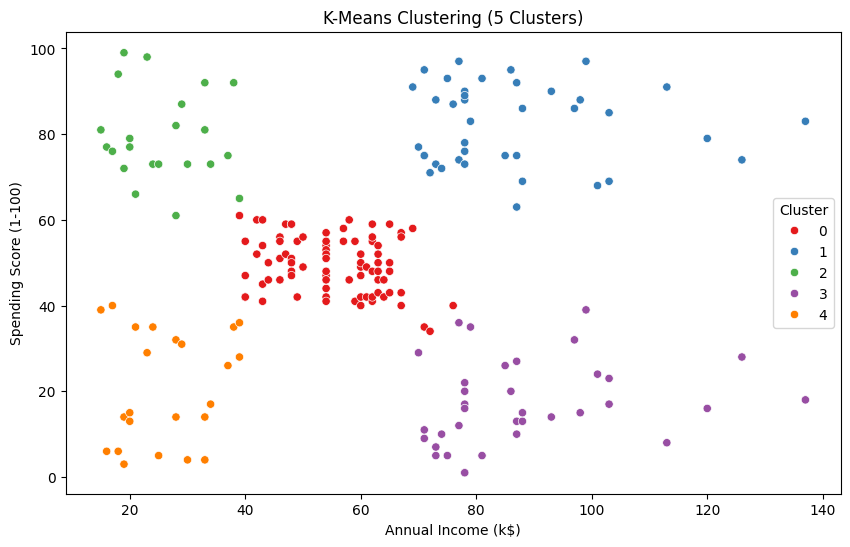

In [46]:
kmeans = KMeans(n_clusters=5, random_state=42)  
data['Cluster'] = kmeans.fit_predict(X)  

plt.figure(figsize=(10, 6))  
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=data, palette='Set1')  
plt.title('K-Means Clustering (5 Clusters)')  
plt.xlabel('Annual Income (k$)')  
plt.ylabel('Spending Score (1-100)')  
plt.legend(title='Cluster')  
plt.show()  

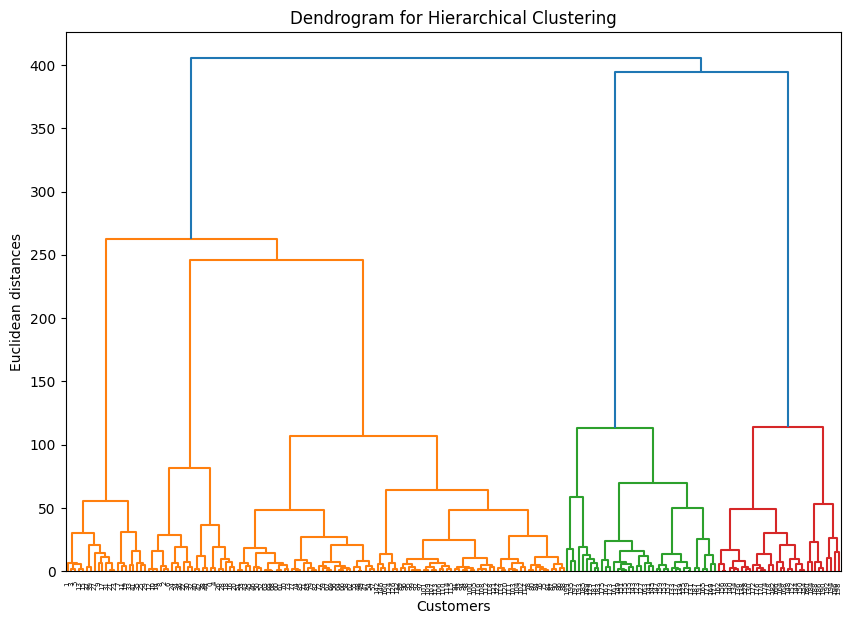

In [47]:
import scipy.cluster.hierarchy as sch  

plt.figure(figsize=(10, 7))  
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))  
plt.title('Dendrogram for Hierarchical Clustering')  
plt.xlabel('Customers')  
plt.ylabel('Euclidean distances')  
plt.show()  

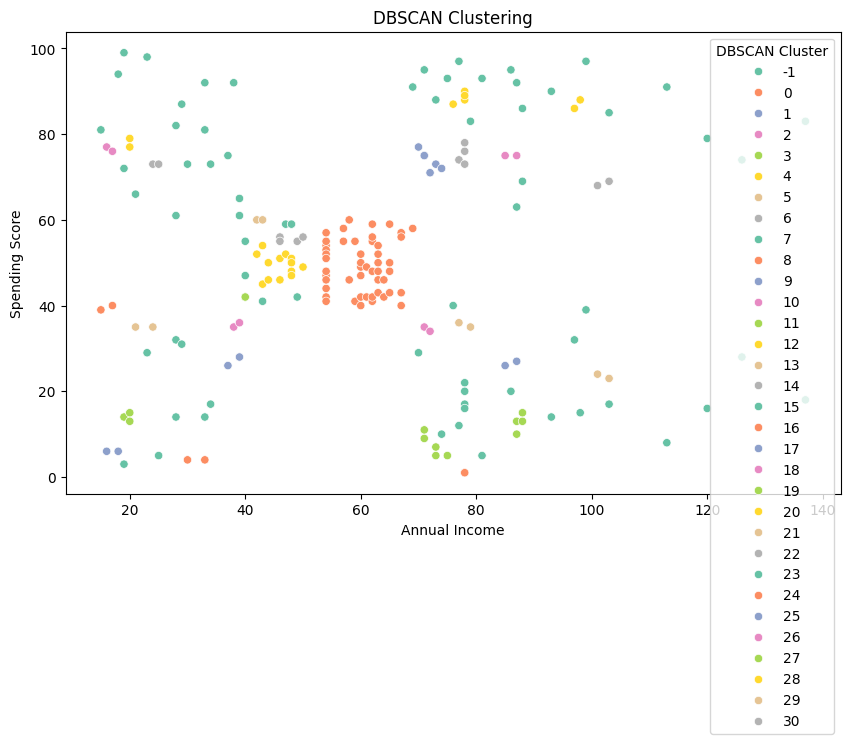

In [49]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3, min_samples=2)
data['DBSCAN_Cluster'] = dbscan.fit_predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=data, palette='Set2')
plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='DBSCAN Cluster')
plt.show()


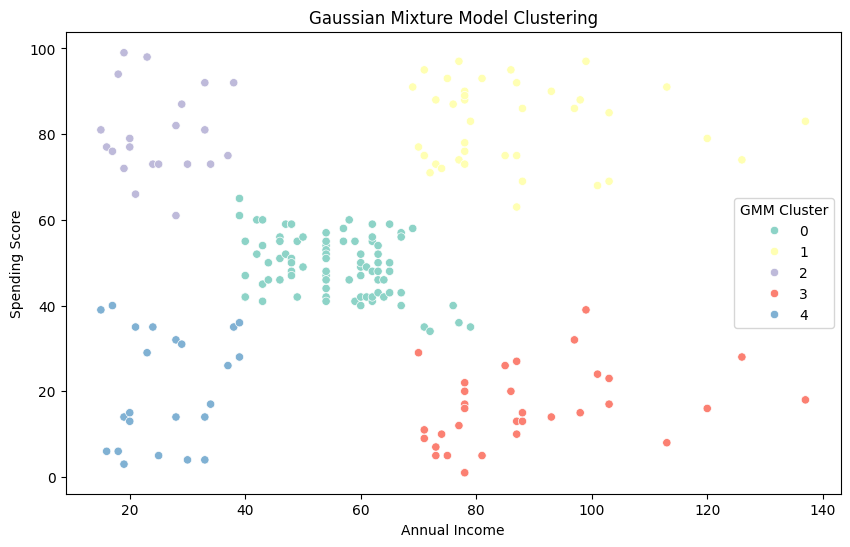

In [50]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
data['GMM_Cluster'] = gmm.fit_predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='GMM_Cluster', data=data, palette='Set3')
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='GMM Cluster')
plt.show()
